___

<a href='http://www.pieriandata.com'> <img src='../Pierian_Data_Logo.png' /></a>
___

# Finance Data Project 

In this data project we will focus on exploratory data analysis of stock prices. Keep in mind, this project is just meant to practice your visualization and pandas skills, it is not meant to be a robust financial analysis or be taken as financial advice.
____
** NOTE: This project is extremely challenging because it will introduce a lot of new concepts and have you looking things up on your own (we'll point you in the right direction) to try to solve the tasks issued. Feel free to just go through the solutions lecture notebook and video as a "walkthrough" project if you don't want to have to look things up yourself. You'll still learn a lot that way! **
____
We'll focus on bank stocks and see how they progressed throughout the [financial crisis](https://en.wikipedia.org/wiki/Financial_crisis_of_2007%E2%80%9308) all the way to early 2016.

In [30]:
%pip install yfinance

from pandas_datareader import data, wb
import pandas as pd
import numpy as np
import seaborn as sns
import datetime
import yfinance as yf
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


## Data

We need to get data using pandas datareader. We will get stock information for the following banks:
*  Bank of America
* CitiGroup
* Goldman Sachs
* JPMorgan Chase
* Morgan Stanley
* Wells Fargo


In [4]:
start = datetime.datetime(2020,1,1)
end = datetime.datetime(2021,1,1)

In [16]:
BAC =yf.download("BAC",start,end)
C=yf.download("C",start,end)
GS=yf.download("GS",start,end)
JPM=yf.download("JPM",start,end)
MS=yf.download("MS",start,end)
WFC=yf.download("WFC",start,end)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [18]:
stocks = ['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']
df = yf.download(stocks, start=start, end=end)

[*********************100%***********************]  6 of 6 completed


** Create a list of the ticker symbols (as strings) in alphabetical order. Call this list: tickers**

In [19]:
tickers = ['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']

** Use pd.concat to concatenate the bank dataframes together to a single data frame called bank_stocks. Set the keys argument equal to the tickers list. Also pay attention to what axis you concatenate on.**

In [20]:
bank_stocks = pd.concat([BAC, C, GS, JPM, MS, WFC],axis=1,keys=tickers)

** Check the head of the bank_stocks dataframe.**

In [21]:
bank_stocks.head()


BAC                                                      C  \
Price           Close       High        Low       Open    Volume       Close   
Ticker            BAC        BAC        BAC        BAC       BAC           C   
Date                                                                           
2006-01-03  30.487944  30.552700  29.885696  30.384329  16296700  315.803558   
2006-01-04  30.164154  30.591555  30.079968  30.436135  17757900  309.973114   
2006-01-05  30.203005  30.326046  29.995780  30.164152  14970700  311.510925   
2006-01-06  30.157671  30.377847  30.015203  30.306613  12599800  311.510925   
2006-01-09  30.177095  30.416701  30.021678  30.254806  15619400  310.037201   

                                                         ...         MS  \
Price             High         Low        Open   Volume  ...      Close   
Ticker               C           C           C        C  ...         MS   
Date                                                     ...              
2006-01-03  316.380189  308.243246  313.945517  1537600  ...  31.182055   
2006-01-04  314.586198  309.780910  313.048510  1870960  ...  31.203438   
2006-01-05  312.536038  310.101366  310.357644  1143160  ...  31.289011   
2006-01-06  313.304892  308.819955  313.176743  1370210  ...  31.321085   
2006-01-09  312.279669  309.460570  311.382686  1680740  ...  31.652639   

                                                            WFC             \
Price            High        Low       Open   Volume      Close       High   
Ticker             MS         MS         MS       MS        WFC        WFC   
Date                                                                         
2006-01-03  31.278312  30.342476  30.572423  5377000  18.379139  18.422351   
2006-01-04  31.700768  31.203438  31.390606  7977800  18.165962  18.333045   
2006-01-05  31.331793  31.026978  31.310402  5778000  18.145805  18.180374   
2006-01-06  31.470818  31.043008  31.428038  6889800  18.252394  18.307127   
2006-01-09  31.706117  31.347824  31.353173  4144500  18.249506  18.335929   

                                            
Price             Low       Open    Volume  
Ticker            WFC        WFC       WFC  
Date                                        
2006-01-03  17.972954  18.206295  11016400  
2006-01-04  18.070897  18.321521  10870000  
2006-01-05  18.039217  18.148686  10158000  
2006-01-06  18.082430  18.194779   8403800  
2006-01-09  18.180369  18.249506   5619600  

[5 rows x 30 columns]

# EDA

Let's explore the data a bit! Before continuing, I encourage you to check out the documentation on [Multi-Level Indexing](http://pandas.pydata.org/pandas-docs/stable/advanced.html) and [Using .xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html).
Reference the solutions if you can not figure out how to use .xs(), since that will be a major part of this project.

** What is the max Close price for each bank's stock throughout the time period?**

In [25]:
bank_stocks.xs(key='Close',axis=1,level='Price').max()

     Ticker
BAC  BAC        36.870289
C    C         376.505310
GS   GS        228.548264
JPM  JPM       117.011749
MS   MS         48.881321
WFC  WFC        52.508007
dtype: float64

** Create a new empty DataFrame called returns. This dataframe will contain the returns for each bank's stock. returns are typically defined by:**

$$r_t = \frac{p_t - p_{t-1}}{p_{t-1}} = \frac{p_t}{p_{t-1}} - 1$$

In [26]:
returns = pd.DataFrame()

** We can use pandas pct_change() method on the Close column to create a column representing this return value. Create a for loop that goes and for each Bank Stock Ticker creates this returns column and set's it as a column in the returns DataFrame.**

In [41]:
for tick in stocks:
    returns[tick+' Return'] = bank_stocks[tick]['Close'].pct_change()
returns.head()

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return,BACReturn,CReturn,GSReturn,JPMReturn,MSReturn,WFCReturn
Date,,,,,,,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013812,-0.005772,0.000686,-0.011599,-0.010620,-0.018462,-0.013812,-0.005772,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001110,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001110
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005874,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005874
2006-01-09,0.000644,-0.004731,0.012031,0.016241,0.010586,-0.000158,0.000644,-0.004731,0.012031,0.016241,0.010586,-0.000158


** Create a pairplot using seaborn of the returns dataframe. What stock stands out to you? Can you figure out why?**

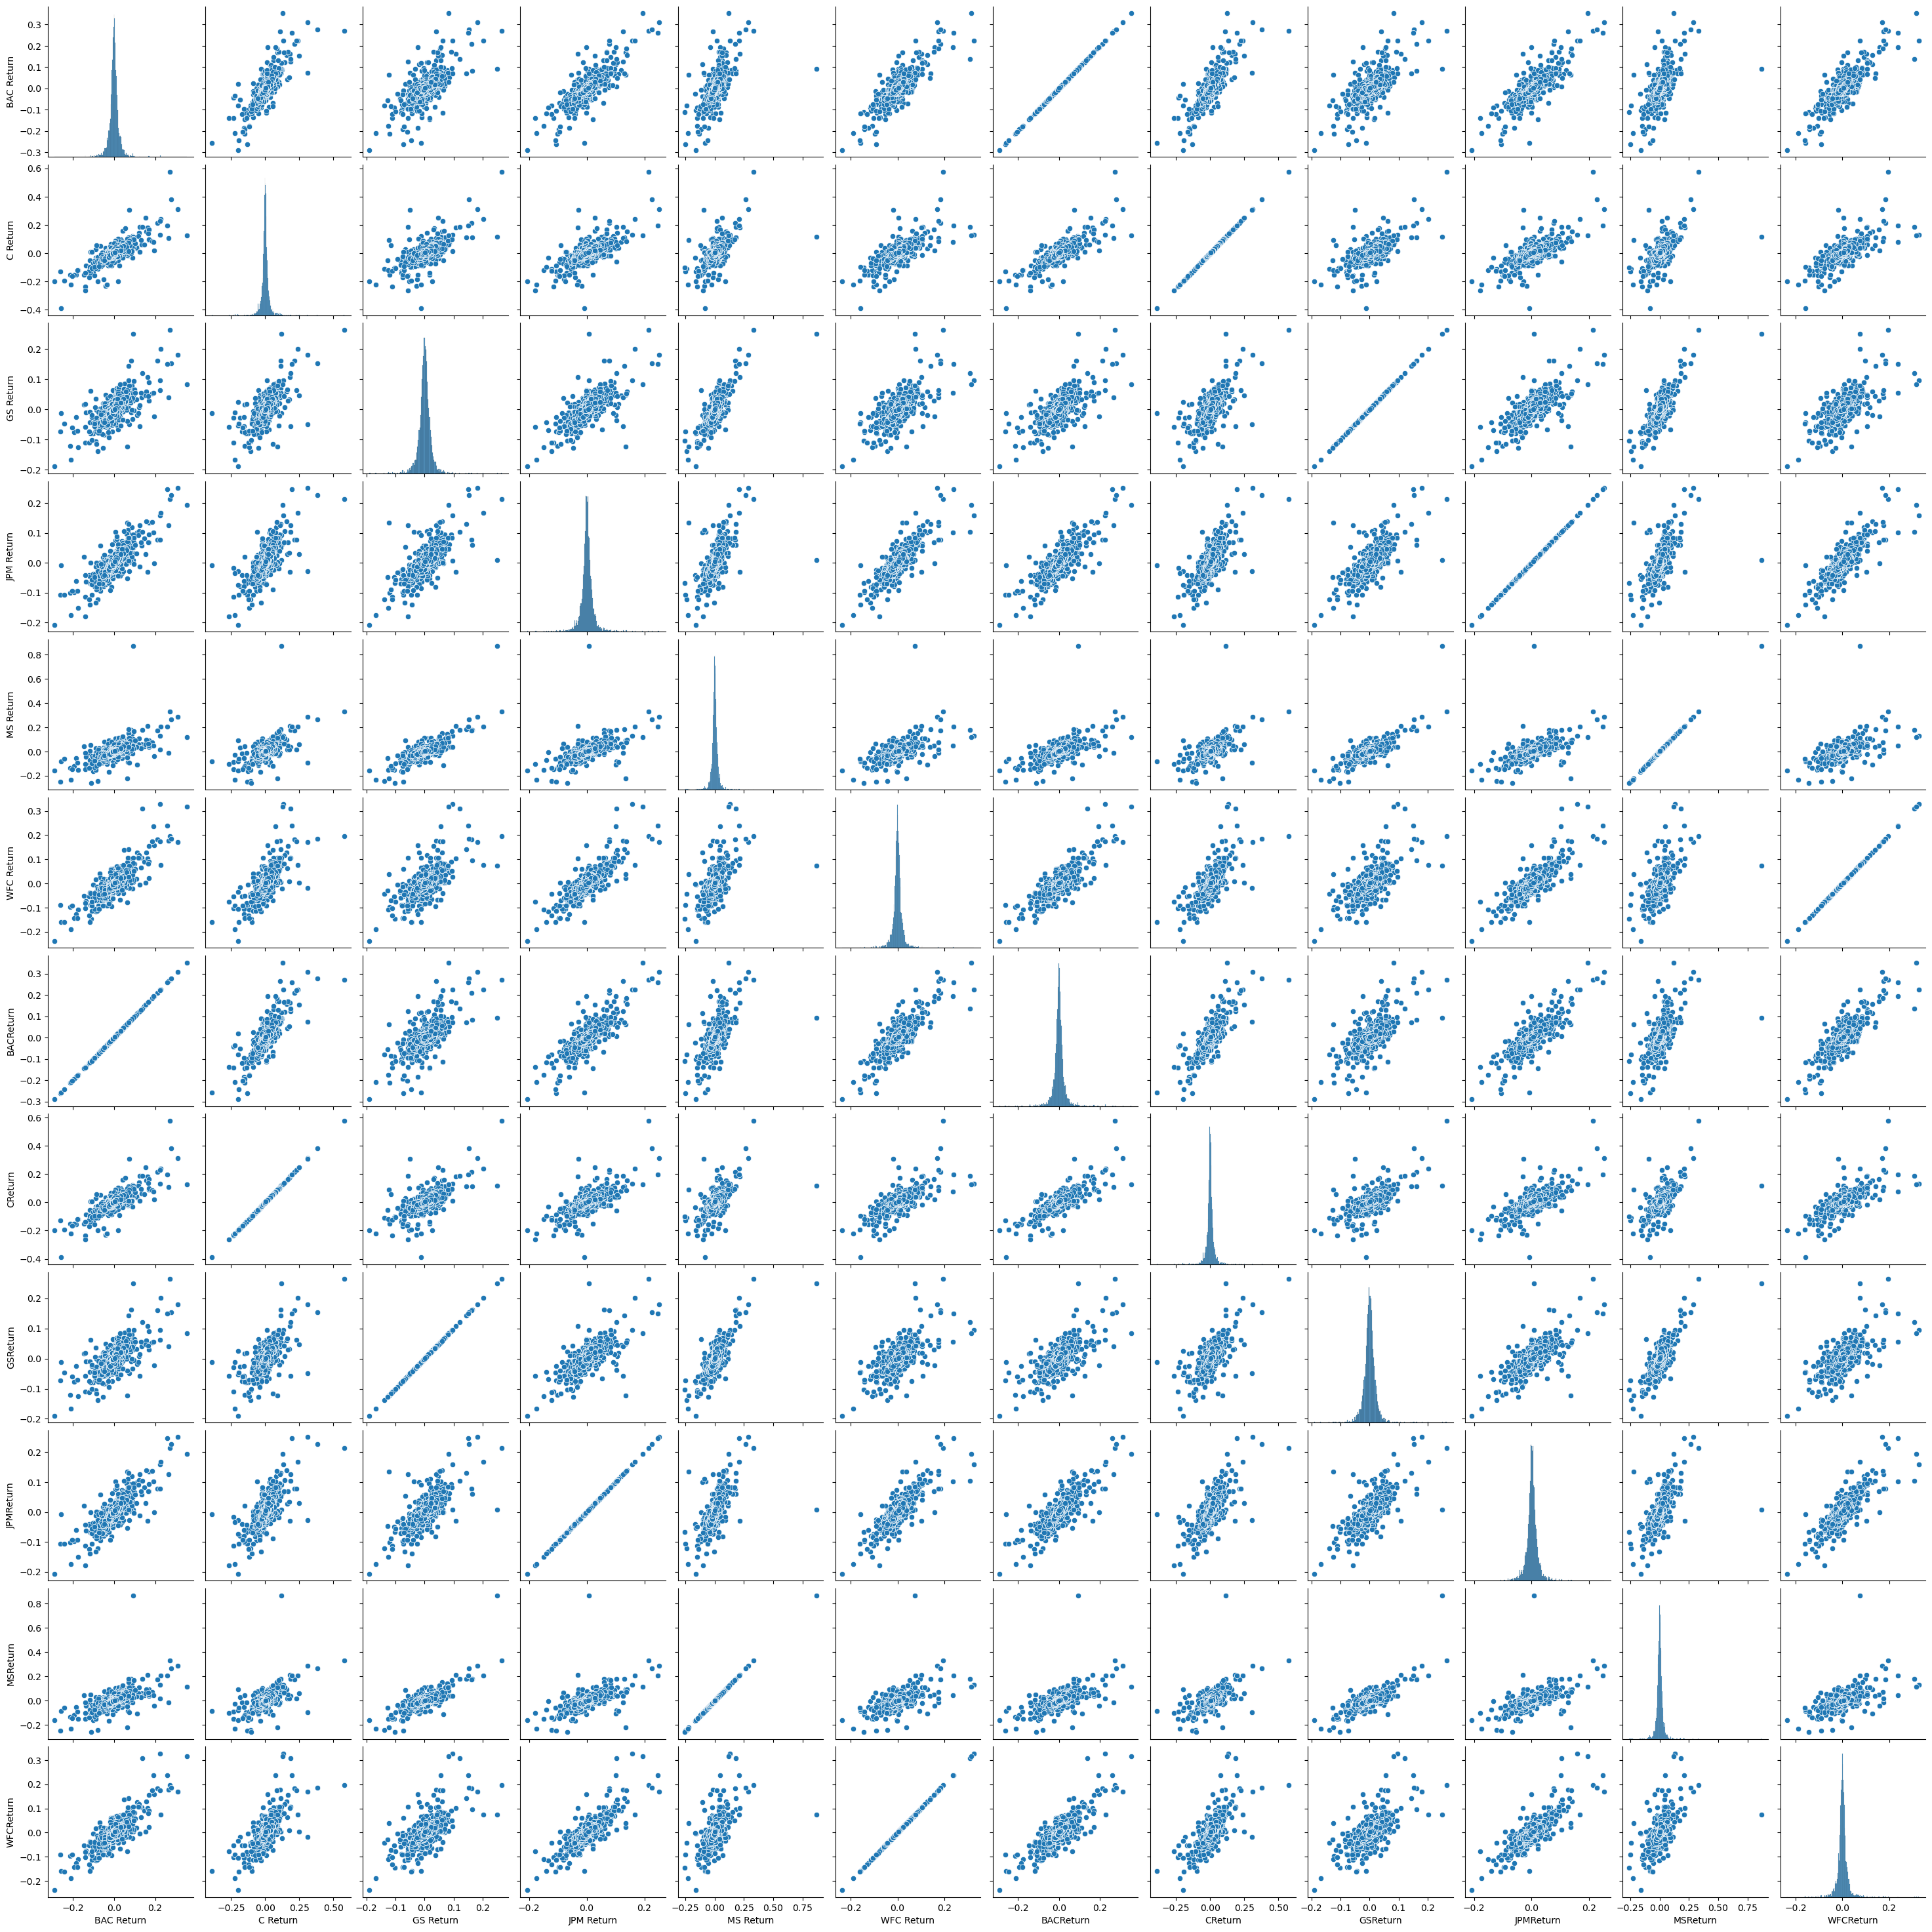

In [42]:
import matplotlib.pyplot as plt
sns.pairplot(returns[1:])
plt.show()

* See solution for details about Citigroup behavior....

** Using this returns DataFrame, figure out on what dates each bank stock had the best and worst single day returns. You should notice that 4 of the banks share the same day for the worst drop, did anything significant happen that day?**

In [43]:
returns.idxmin()

BAC Return   2009-01-20
C Return     2009-02-27
GS Return    2009-01-20
JPM Return   2009-01-20
MS Return    2008-10-09
WFC Return   2009-01-20
BACReturn    2009-01-20
CReturn      2009-02-27
GSReturn     2009-01-20
JPMReturn    2009-01-20
MSReturn     2008-10-09
WFCReturn    2009-01-20
dtype: datetime64[ns]

** You should have noticed that Citigroup's largest drop and biggest gain were very close to one another, did anythign significant happen in that time frame? **

* See Solution for details

In [ ]:
returns.idxmax()

BAC Return   2009-04-09
C Return     2011-05-09
GS Return    2008-11-24
JPM Return   2009-01-21
MS Return    2008-10-13
WFC Return   2008-07-16
dtype: datetime64[ns]

** Take a look at the standard deviation of the returns, which stock would you classify as the riskiest over the entire time period? Which would you classify as the riskiest for the year 2015?**

In [ ]:
returns.std()

BAC Return    0.036650
C Return      0.179969
GS Return     0.025346
JPM Return    0.027656
MS Return     0.037820
WFC Return    0.030233
dtype: float64

In [51]:
returns.loc['2015-01-01':'2015-12-31'].std()

BAC Return    0.016174
C Return      0.015288
GS Return     0.014043
JPM Return    0.014006
MS Return     0.016287
WFC Return    0.012552
BACReturn     0.016174
CReturn       0.015288
GSReturn      0.014043
JPMReturn     0.014006
MSReturn      0.016287
WFCReturn     0.012552
dtype: float64

** Create a distplot using seaborn of the 2015 returns for Morgan Stanley **

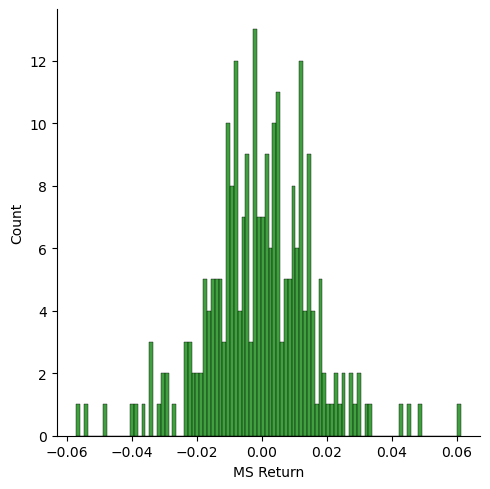

In [50]:
sns.displot(returns.loc['2015-01-01':'2015-12-31']['MS Return'],color='green',bins=100)
plt.show()

** Create a distplot using seaborn of the 2008 returns for CitiGroup **

C:\Users\Meet Barot\AppData\Local\Temp\ipykernel_21292\3291767074.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(returns.loc['2008-01-01':'2008-12-31']['C Return'],color='red',bins=100)


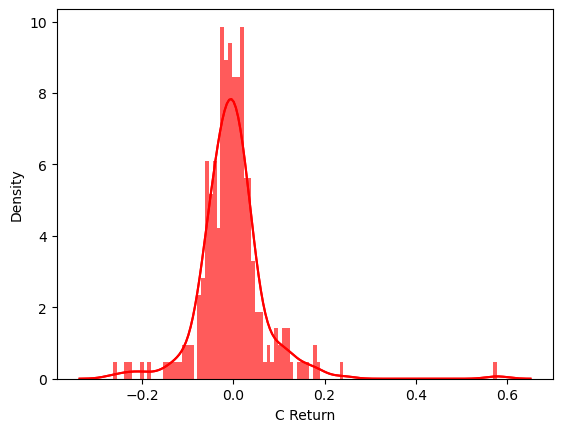

In [53]:
sns.distplot(returns.loc['2008-01-01':'2008-12-31']['C Return'],color='red',bins=100)
plt.show()

____
# More Visualization

A lot of this project will focus on visualizations. Feel free to use any of your preferred visualization libraries to try to recreate the described plots below, seaborn, matplotlib, plotly and cufflinks, or just pandas.

### Imports

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

# Optional Plotly Method Imports
import plotly
import cufflinks as cf
cf.go_offline()

** Create a line plot showing Close price for each bank for the entire index of time. (Hint: Try using a for loop, or use [.xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html) to get a cross section of the data.)**

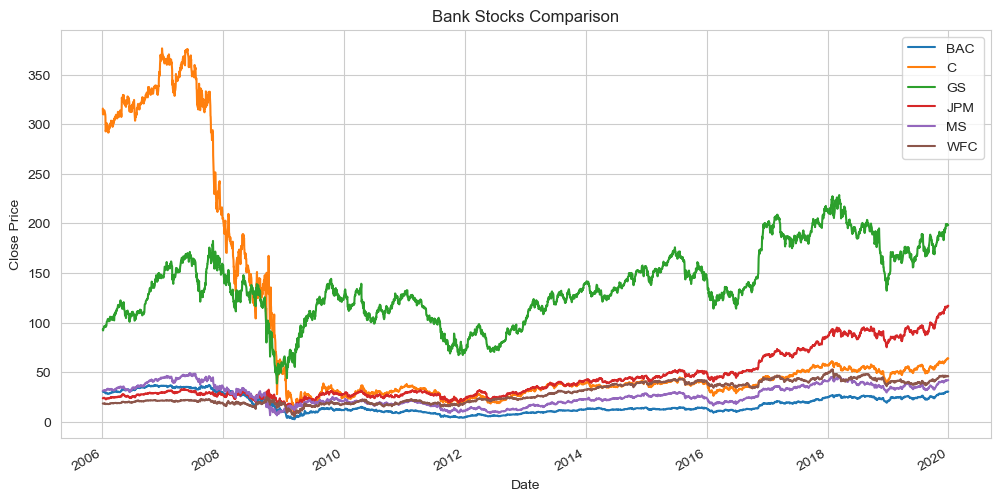

In [61]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,6))   

for tick in stocks:
    bank_stocks[tick]['Close'].plot(ax=ax, label=tick)

ax.legend()
ax.set_title("Bank Stocks Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")

plt.show()

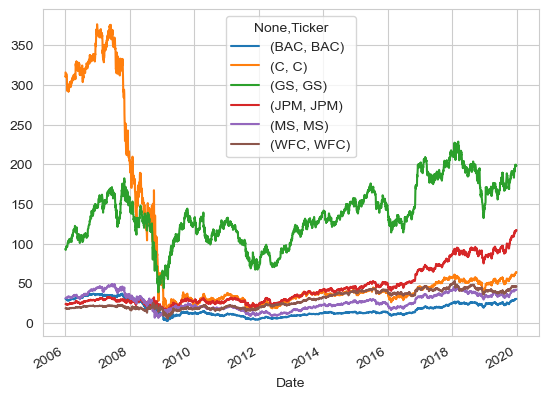

In [65]:
bank_stocks.xs(key='Close',axis=1,level='Price').plot()
plt.show()

In [66]:
bank_stocks.xs(key='Close',axis=1,level='Price').iplot()


c:\Users\Meet Barot\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



## Moving Averages

Let's analyze the moving averages for these stocks in the year 2008. 

** Plot the rolling 30 day average against the Close Price for Bank Of America's stock for the year 2008**

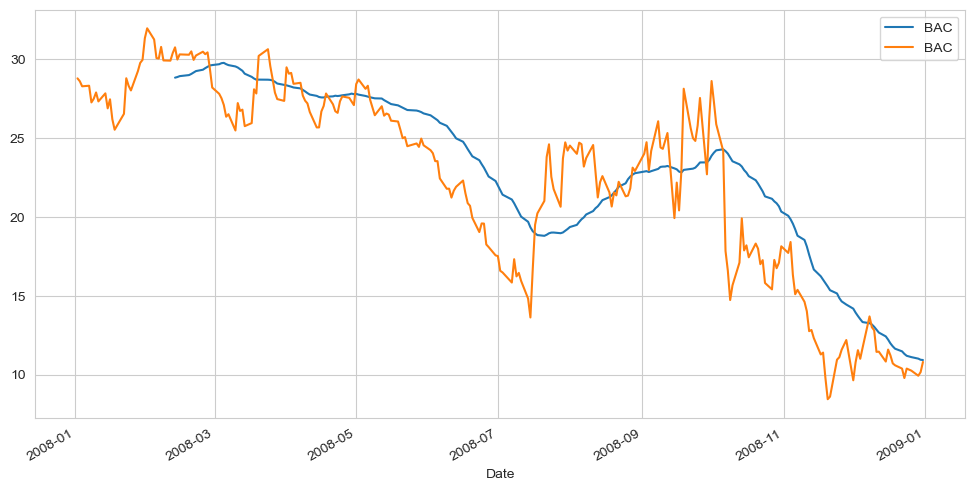

In [71]:
fig, ax = plt.subplots(figsize=(12,6))

BAC['Close'].loc['2008-01-01':'2009-01-01'] \
    .rolling(window=30).mean() \
    .plot(ax=ax, label='30 Day Avg')

BAC['Close'].loc['2008-01-01':'2009-01-01'] \
    .plot(ax=ax, label='BAC CLOSE')

ax.legend()
plt.show()

** Create a heatmap of the correlation between the stocks Close Price.**

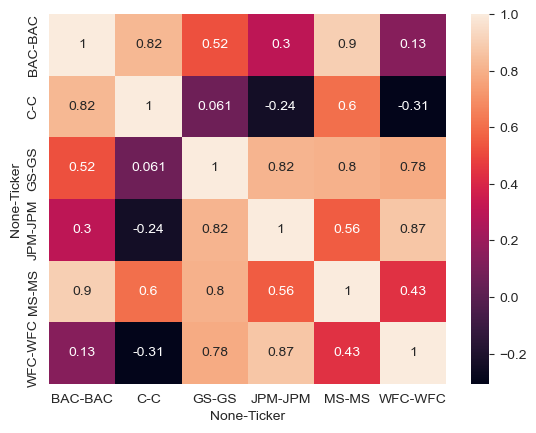

In [77]:
sns.heatmap(bank_stocks.xs(key='Close',axis=1,level='Price').corr(),annot=True)
plt.show()

** Optional: Use seaborn's clustermap to cluster the correlations together:**

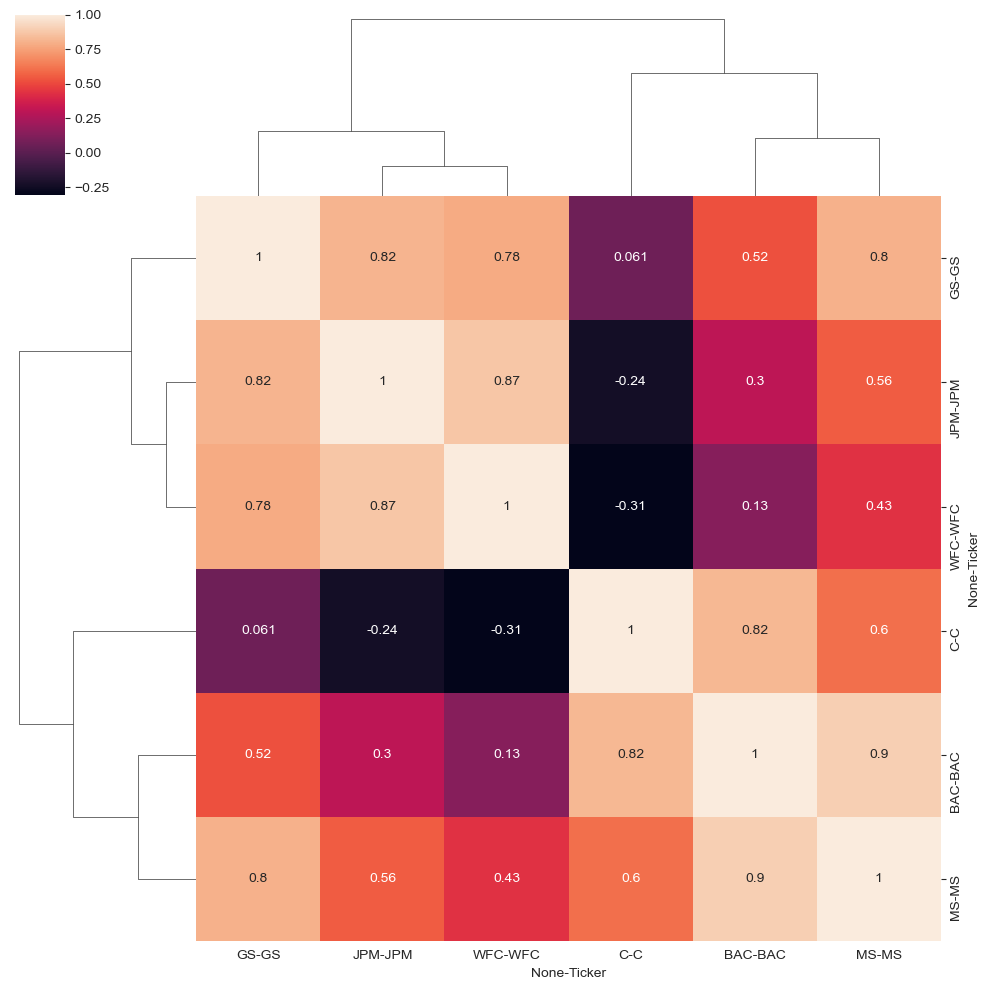

In [78]:
sns.clustermap(bank_stocks.xs(key='Close',axis=1,level='Price').corr(),annot=True)
plt.show()

** Use .iplot(kind='candle) to create a candle plot of Bank of America's stock from Jan 1st 2015 to Jan 1st 2016.**

In [89]:
BAC_ohlc = bank_stocks.xs('BAC', axis=1, level=0)

In [91]:
BAC_ohlc = BAC_ohlc.droplevel(level='Ticker', axis=1)
BAC_ohlc[['Open','High','Low','Close','Volume']].loc['2015-01-01':'2016-01-01'].iplot(kind='candle')


** Use .ta_plot(study='sma') to create a Simple Moving Averages plot of Morgan Stanley for the year 2015.**

In [93]:
MS['Close'].loc['2015-01-01':'2016-01-01'].ta_plot(study='sma',periods=[13,21,55],title='Simple Moving Averages')

c:\Users\Meet Barot\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.

c:\Users\Meet Barot\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



**Use .ta_plot(study='boll') to create a Bollinger Band Plot for Bank of America for the year 2015.**

In [94]:
BAC['Close'].loc['2015-01-01':'2016-01-01'].ta_plot(study='boll')

c:\Users\Meet Barot\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.

c:\Users\Meet Barot\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.

